## **Programación**

In [24]:
# Importación de librerías
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon
from IPython.display import display

In [2]:
# Verificación de carpetas completas (sujetos completos)

# Carpeta de datos
ruta = 'ds004362'

# Detectar carpetas de sujetos
sujetos = [s for s in os.listdir(ruta) if s.startswith('sub-')]

print(sujetos)

['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043', 'sub-044', 'sub-045', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066', 'sub-067', 'sub-068', 'sub-069', 'sub-070', 'sub-071', 'sub-072', 'sub-073', 'sub-074', 'sub-075', 'sub-076', 'sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-081', 'sub-082', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-087', 'sub-088', 'sub-089', 'sub-090', 'sub-091'

**1. Muestra de procesamiento de datos para un sujeto**

In [77]:
sujeto = "sub-001"         # Sujeto a analizar

# Flujo de procesamiento

# 1. Carga de datos

# Selección de los archivos que contienen la información requerida
runs_real = ['run-3', 'run-7', 'run-11'] # Archivos movimiento real
runs_imag = ['run-4', 'run-8', 'run-12'] # Archivos imaginación de movimiento

# Selección de rutas
ruta_sujeto = os.path.join(ruta, sujeto, "eeg") # Ruta para acceder a las carpeta, en este caso sub-001
archivos = [f for f in os.listdir(ruta_sujeto) if f.endswith('.set')] # Recorre los archivos en la carpeta seleccionada

senal_r = [] # Lista para almacenar 
senal_i = []

ruta_archivo = os.path.join(ruta_sujeto, archivo)

for archivo in archivos:

    # Seleccionar solo los runs deseados
    if any(run in archivo for run in runs_real):
        raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
        senal_r.append(raw)

    elif any(run in archivo for run in runs_imag):
        raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
        senal_i.append(raw)

# Concatenar
raw_real = mne.concatenate_raws(senal_r)
raw_imag = mne.concatenate_raws(senal_i)


# 2. Selección de canales de importancia
canales = ['C3', 'C4']
raw_real.pick_channels(canales)
raw_imag.pick_channels(canales)

# 3. Filtrado de la señal

# Señal real 
raw_real_original = raw_real.copy() # Copia de la señal real original
raw_real_filt = raw_real.copy().filter(8., 30., fir_window='hamming', verbose=False) # Filtrado de banda 8-30 Hz

# Señal imaginaria
raw_imag_original = raw_imag.copy() # Copia de la señal imaginaria original
raw_imag_filt = raw_imag.copy().filter(8., 30., fir_window='hamming', verbose=False)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


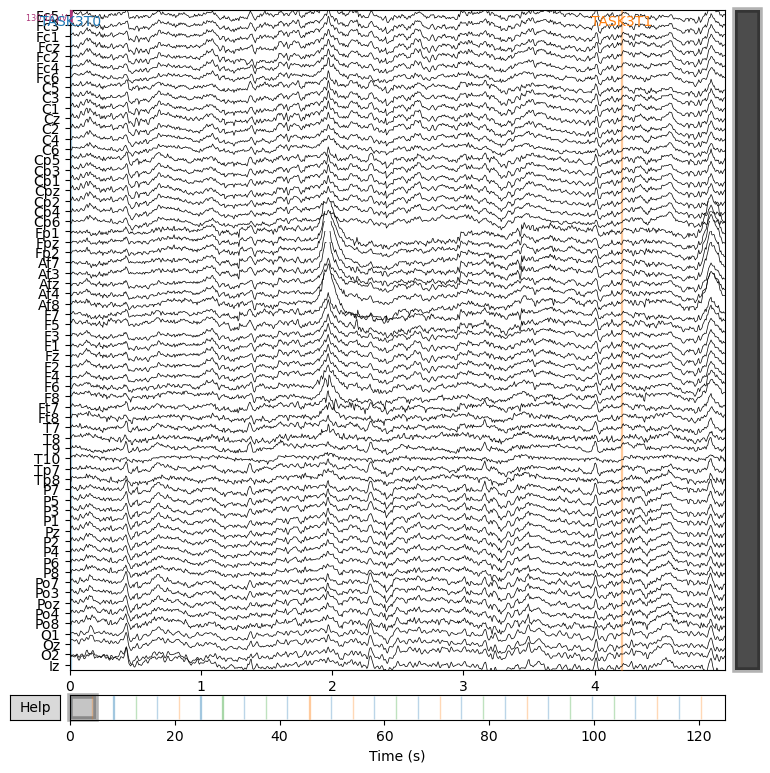

In [78]:
# Graficar la serie de tiempo de todos los canales
raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
raw.plot(n_channels=len(raw.ch_names), duration=5.0, scalings='auto');

<Figure size 1400x1000 with 0 Axes>

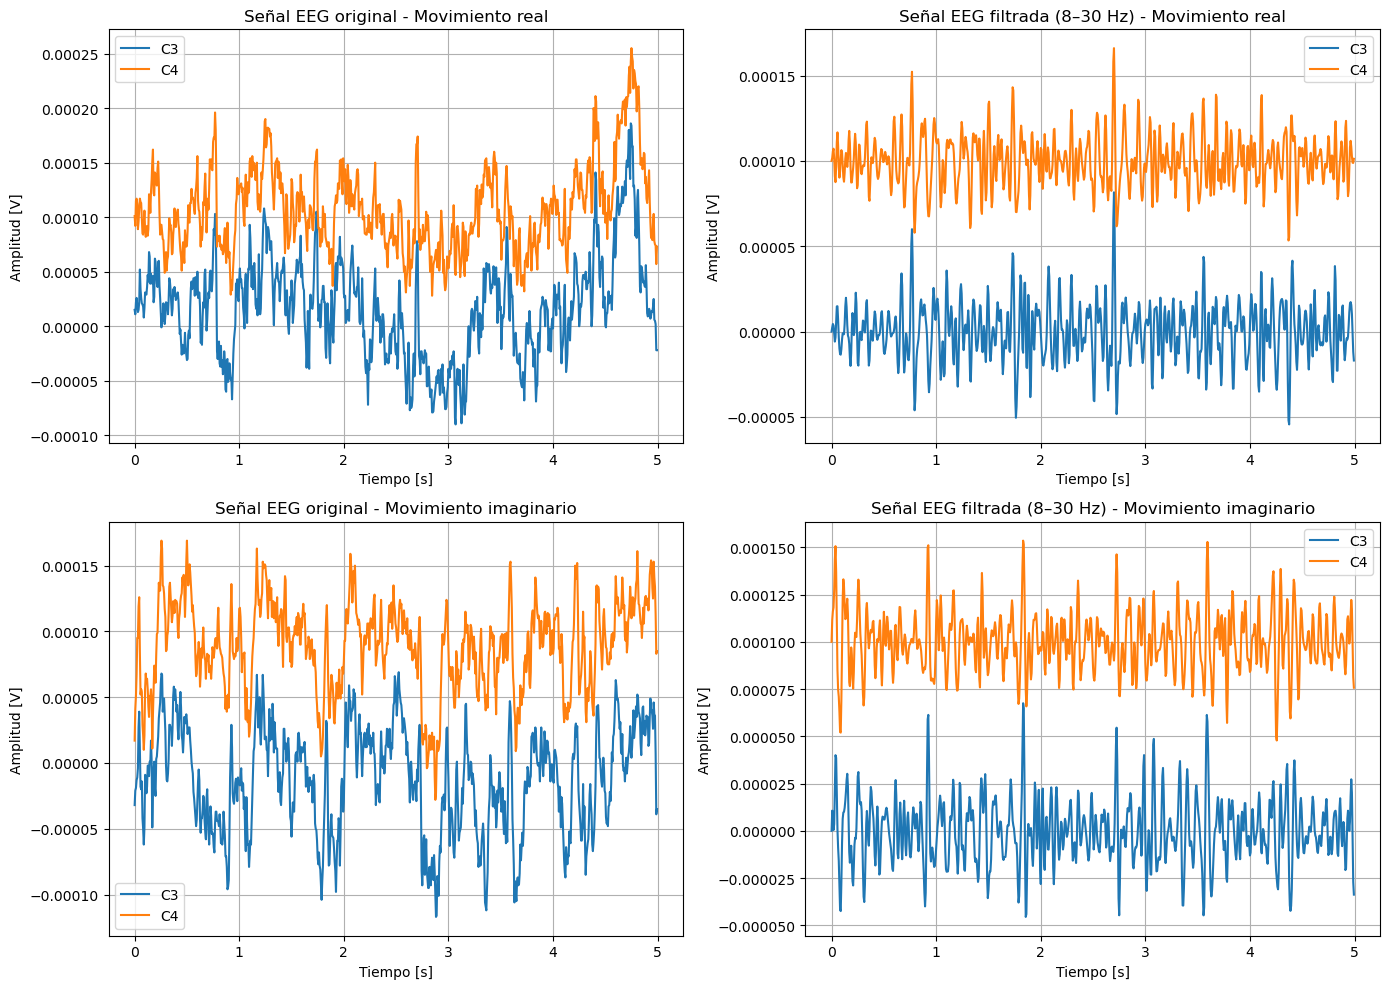

In [ ]:
# Visualización del efecto de los filtros

inicio = 0
duracion = 5  # segundos

sfreq = raw.info['sfreq']
ini = int(inicio * sfreq)
fin = int((inicio + duracion) * sfreq)

times = raw.times[ini:fin]

# A. Señal movimiento real
real_orig = raw_real_original.get_data()[:, ini:fin]
real_filt = raw_real_filt.get_data()[:, ini:fin]

# B. Señal movimiento imaginación
img_orig = raw_imag_original.get_data()[:, ini:fin]
img_filt = raw_imag_filt.get_data()[:, ini:fin]

# Offset para separar canales visualmente
offset = 1e-4

# Gráficas
plt.figure(figsize=(14,10))

# A. Señal movimiento real 

# Original
plt.subplot(2,2,1)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, real_orig[i] + i*offset, label=ch)
plt.title("Señal EEG original - Movimiento real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

# Filtrada
plt.subplot(2,2,2)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, real_filt[i] + i*offset, label=ch)
plt.title("Señal EEG filtrada (8–30 Hz) - Movimiento real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

plt.subplot(2,2,3)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, img_orig[i] + i*offset, label=ch)
plt.title("Señal EEG original - Movimiento imaginario")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

plt.subplot(2,2,4)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, img_filt[i] + i*offset, label=ch)
plt.title("Señal EEG filtrada (8–30 Hz) - Movimiento imaginario")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

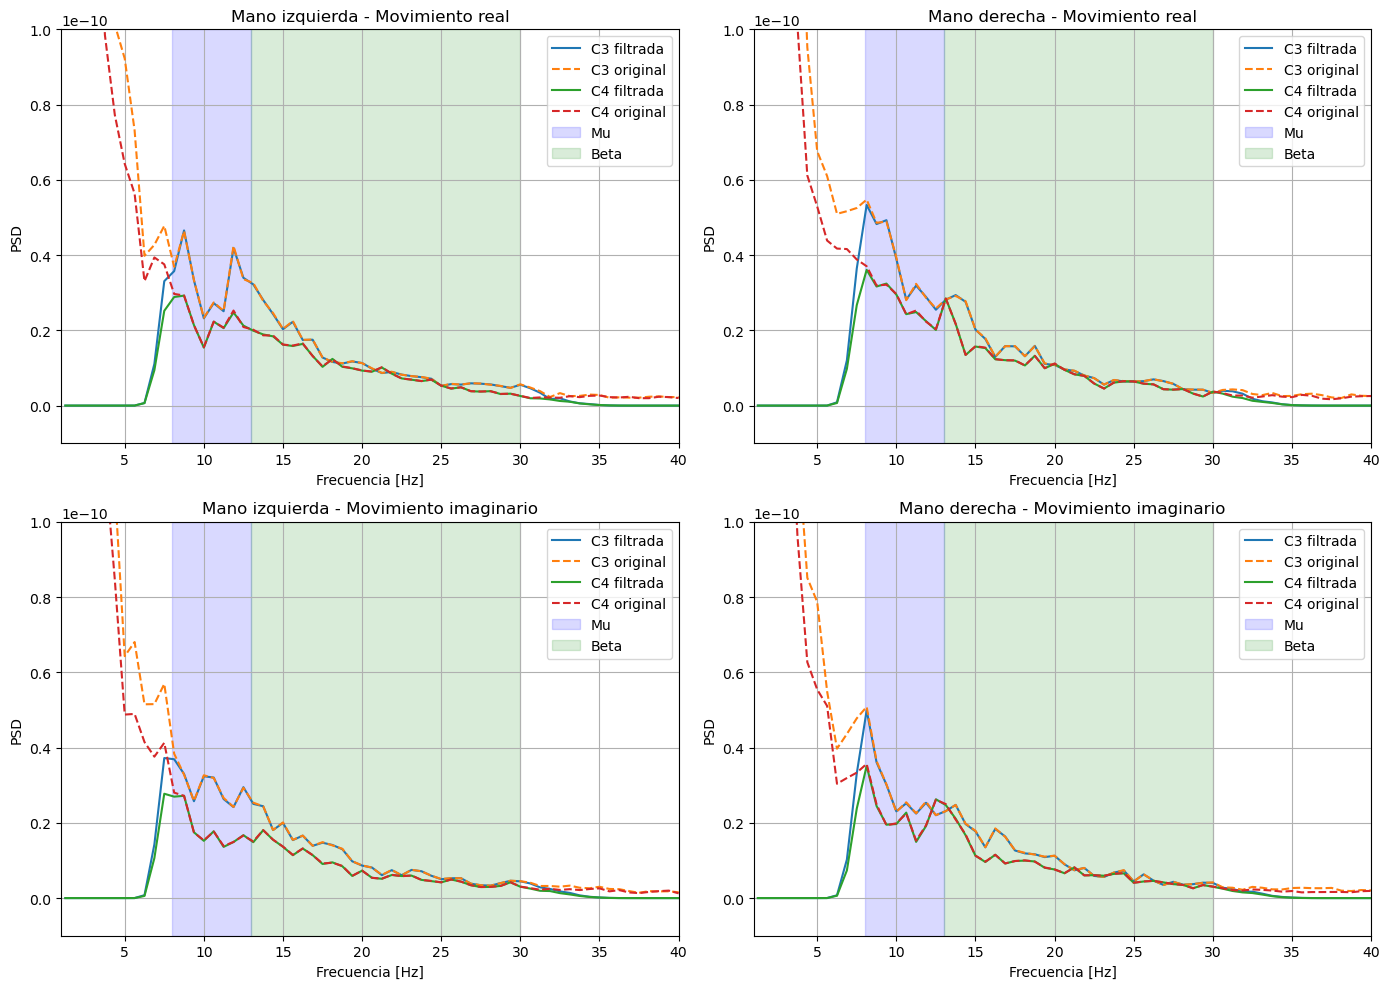

In [ ]:
# 4. PSD

# Eventos
events_r_orig, event_id_r = mne.events_from_annotations(raw_real_original, verbose=False)
events_r_filt, _ = mne.events_from_annotations(raw_real_filt, verbose=False)

events_i_orig, event_id_i = mne.events_from_annotations(raw_imag_original, verbose=False)
events_i_filt, _ = mne.events_from_annotations(raw_imag_filt, verbose=False)

# Épocas
epochs_real_orig = mne.Epochs(raw_real_original, events_r_orig, event_id=event_id_r,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_real_filt = mne.Epochs(raw_real_filt, events_r_filt, event_id=event_id_r,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_imag_orig = mne.Epochs(raw_imag_original, events_i_orig, event_id=event_id_i,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_imag_filt = mne.Epochs(raw_imag_filt, events_i_filt, event_id=event_id_i,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

# Condiciones de estudio
condiciones = [
    ("Mano_izquierda_-_Movimiento_real", epochs_real_orig['TASK1T1'], epochs_real_filt['TASK1T1']),
    ("Mano_derecha_-_Movimiento_real", epochs_real_orig['TASK1T2'], epochs_real_filt['TASK1T2']),
    ("Mano_izquierda_-_Movimiento_imaginario", epochs_imag_orig['TASK2T1'], epochs_imag_filt['TASK2T1']),
    ("Mano_derecha_-_Movimiento_imaginario", epochs_imag_orig['TASK2T2'], epochs_imag_filt['TASK2T2'])
]

# Gráfica
plt.figure(figsize=(14,10))

for i, (nombre, ep_orig, ep_filt) in enumerate(condiciones):

    # Seleccionar canales
    picks = mne.pick_channels(ep_orig.ch_names, include=canales)

    datos_orig = ep_orig.get_data()[:, picks, :]
    datos_filt = ep_filt.get_data()[:, picks, :]

    # PSD
    psd_orig, freqs = mne.time_frequency.psd_array_welch(datos_orig, sfreq=sfreq, fmin=1, fmax=40, verbose=False)
    
    psd_filt, _ = mne.time_frequency.psd_array_welch(datos_filt, sfreq=sfreq, fmin=1, fmax=40, verbose=False)

    # Promedio sobre épocas 
    psd_orig_mean = psd_orig.mean(axis=0)
    psd_filt_mean = psd_filt.mean(axis=0)

    # Gráfica
    plt.subplot(2,2,i+1)

    for ch_idx, ch in enumerate(canales):
        
        # Filtrada (línea sólida)
        plt.plot(freqs, psd_filt_mean[ch_idx],
                 label=f"{ch} filtrada")

        # Original (línea punteada)
        plt.plot(freqs, psd_orig_mean[ch_idx],
                 linestyle='--',
                 label=f"{ch} original")

    # Bandas
    plt.axvspan(8, 13, alpha=0.15, label='Mu', color = "b")
    plt.axvspan(13, 30, alpha=0.15, label='Beta', color = "g")

    plt.title(nombre.replace("_", " "))
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("PSD")
    plt.xlim(1,40)
    plt.ylim(-0.1e-10,1e-10)
    plt.grid()

    plt.legend()

plt.tight_layout()
plt.show()

**2. Procesamiento de todos los sujetos**

In [25]:
# Función filtrado de señales

def filtrar(senal):
    s_filt = senal.copy().filter(8., 30., fir_window='hamming', verbose=False)

    return s_filt

In [26]:
# Función para el cálculo de PSD

def calcular_psd(epocas, sfreq, canales, nombre_cond, sujeto):

# Delta y theta ya están filtradas, por lo que no atribuyen información relevante

    bandas = {
        "mu": (8, 12),
        "beta": (13, 30)
    }

    psd, freqs = mne.time_frequency.psd_array_welch(
        epocas, sfreq=sfreq, fmin=1, fmax=40, verbose=False
    )

    psd_mean = psd.mean(axis=0)  # (canales, frecuencias)

    fila = {
        "sujeto": sujeto,
        "tarea": nombre_cond
    }

    # Calcular potencia por banda y canal
    for banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)
        potencia_banda = psd_mean[:, idx].mean(axis=1)

        for i, ch in enumerate(canales):
            fila[f"{banda}_{ch}"] = potencia_banda[i]

    return pd.DataFrame([fila])

In [49]:
# Función principal: Procesamiento de señales EEG

def procesamiento_eeg(ruta, inicio, fin, archivo_salida="resultados_psd.csv"):
    
    sujetos = [s for s in os.listdir(ruta) if s.startswith('sub-')]
    sujetos_rango = sujetos[inicio:fin]
    
    # Ver si ya existe archivo previo
    if os.path.exists(archivo_salida):
        df_total = pd.read_csv(archivo_salida)
        sujetos_procesados = set(df_total["sujeto"].unique())
        print(f"Archivo existente cargado ({len(sujetos_procesados)} sujetos ya procesados)")
    else:
        df_total = pd.DataFrame()
        sujetos_procesados = set()
    
    for sujeto in sujetos_rango:
        
        if sujeto in sujetos_procesados:
            print(f"{sujeto} ya procesado, se omite")
            continue
        
        print(f"Procesando {sujeto}")
        
        ruta_sujeto = os.path.join(ruta, sujeto, "eeg")
        archivos = [f for f in os.listdir(ruta_sujeto) if f.endswith('.set')]
        
        runs_real = ['run-3', 'run-7', 'run-11']
        runs_imag = ['run-4', 'run-8', 'run-12']
        
        raws_real = []
        raws_imag = []

        for archivo in archivos:
            ruta_archivo = os.path.join(ruta_sujeto, archivo)

            # Seleccionar solo los runs deseados
            if any(run in archivo for run in runs_real):
                raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
                raws_real.append(raw)

            elif any(run in archivo for run in runs_imag):
                raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
                raws_imag.append(raw)

        # Concatenar
        raw_real = mne.concatenate_raws(raws_real)
        raw_imag = mne.concatenate_raws(raws_imag)


        # 2. Selección de canales de importancia
        canales = ['C3', 'C4']
        raw_real.pick_channels(canales)
        raw_imag.pick_channels(canales)
        
        # Filtrado
        real_filtrado = filtrar(raw_real)
        imag_filtrado = filtrar(raw_imag)
        
        # Eventos
        events_r, event_id_r = mne.events_from_annotations(real_filtrado, verbose=False)
        events_i, event_id_i = mne.events_from_annotations(imag_filtrado, verbose=False)
        
        # Épocas
        epochs_real = mne.Epochs(real_filtrado, events_r, event_id=event_id_r, tmin=0, tmax=4, 
                                 baseline=None,preload=True, verbose=False)
        
        epochs_imag = mne.Epochs(imag_filtrado, events_i, event_id=event_id_i, tmin=0, tmax=4, 
                                    baseline=None, preload=True, verbose=False)
        
        sfreq = raw_real.info['sfreq']
        
        # Separación de las 4 condiciones

        condiciones = {
            "Izquierda_Real": epochs_real['TASK1T1'],
            "Derecha_Real": epochs_real['TASK1T2'],
            "Izquierda_Imagineria": epochs_imag['TASK2T1'],
            "Derecha_Imagineria": epochs_imag['TASK2T2']
        }
        
        # Cálculo del PSD

        for cond, ep in condiciones.items():
            
            datos = ep.get_data()
            
            df_psd = calcular_psd(datos, sfreq, canales, cond, sujeto)
            
            archivo_out = "resultados_psd.csv"

            df_psd.to_csv(archivo_out, mode='a', header=not os.path.exists(archivo_out), index=False)
        
        print(f"{sujeto} procesado")


    print("Sujetos procesados - Proceso finalizado")

In [50]:
procesamiento_eeg(ruta, inicio=0, fin=109)

Procesando sub-001
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-001 procesado
Procesando sub-002
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-002 procesado
Procesando sub-003
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-003 procesado
Procesando sub-004
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-004 procesado
Procesando sub-005
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-005 procesado
Procesando sub-

In [51]:
df = pd.read_csv("resultados_psd.csv")
display(df.head(10))

,sujeto,tarea,mu_C3,mu_C4,beta_C3,beta_C4
0,sub-001,Izquierda_Real,3.329076e-11,2.321973e-11,1.172204e-11,9.324420e-12
1,sub-001,Derecha_Real,3.982709e-11,2.875344e-11,1.141449e-11,9.453425e-12
2,sub-001,Izquierda_Imagineria,3.008143e-11,1.901957e-11,1.004105e-11,7.477993e-12
3,sub-001,Derecha_Imagineria,3.031495e-11,2.223332e-11,1.001947e-11,8.167399e-12
4,sub-002,Izquierda_Real,9.915368e-12,7.428563e-12,6.932007e-12,3.040241e-12
5,sub-002,Derecha_Real,1.043588e-11,9.258689e-12,5.691181e-12,4.007797e-12
6,sub-002,Izquierda_Imagineria,1.120403e-11,8.865947e-12,3.857014e-12,3.113985e-12
7,sub-002,Derecha_Imagineria,9.162451e-12,8.033266e-12,4.178850e-12,3.325014e-12
8,sub-003,Izquierda_Real,3.824666e-11,3.926616e-11,8.950375e-12,8.934723e-12
9,sub-003,Derecha_Real,3.870093e-11,3.514438e-11,8.969046e-12,8.579318e-12


## **Análisis de resultados**

**1. Estadística descriptiva**

In [75]:
def barras_canal(df, canal, mano):

    mu = f"mu_{canal}"
    beta = f"beta_{canal}"

    cond_real = f"{mano}_Real"
    cond_imag = f"{mano}_Imagineria"

    # Promedios 
    mean_real = df[df["tarea"] == cond_real][[mu, beta]].mean()
    mean_imag = df[df["tarea"] == cond_imag][[mu, beta]].mean()

    x = np.arange(2)  # Mu, Beta
    width = 0.35

    plt.bar(x - width/2, mean_real, width, label="Real", capsize=4)
    plt.bar(x + width/2, mean_imag, width, label="Imaginario", capsize=4)

    plt.xticks(x, ["Mu", "Beta"])
    plt.title(f"{canal} - Mano {mano}")
    plt.ylabel("PSD")
    plt.legend()
    plt.grid()
    plt.tight_layout()

def boxplot(ritmo):
    plt.figure(figsize = (14,7))
    sns.boxplot(data=df, x="tarea", y=ritmo)
    plt.title(f"Distribución de la PSD de {ritmo} por condición")
    plt.xlabel("Condición")
    plt.ylabel("PSD")
    plt.grid()

def correlacion(df, columnas, condicion=None):

    df_sub = df
    titulo = "Matriz de correlación - Global"

    corr = df_sub[columnas].corr()
    
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(titulo)

Canal C3


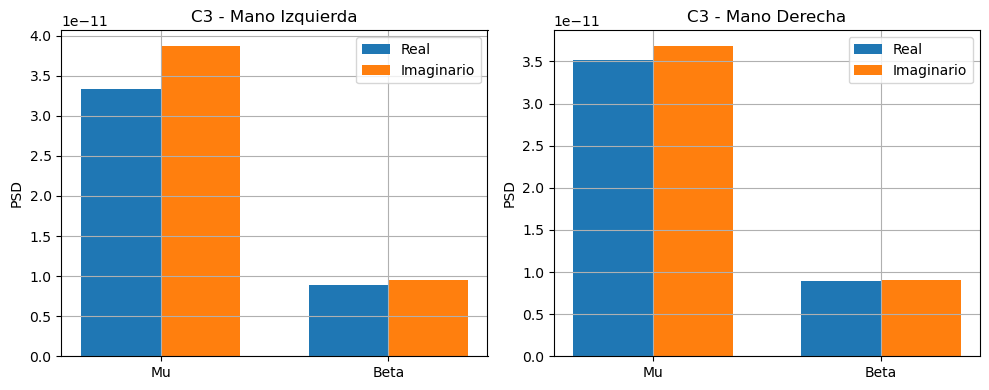

In [60]:
# Canal C3
print("Canal C3")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
barras_canal(df, "C3", "Izquierda")
plt.subplot(1,2,2)
barras_canal(df, "C3", "Derecha")
plt.show()

Canal C4


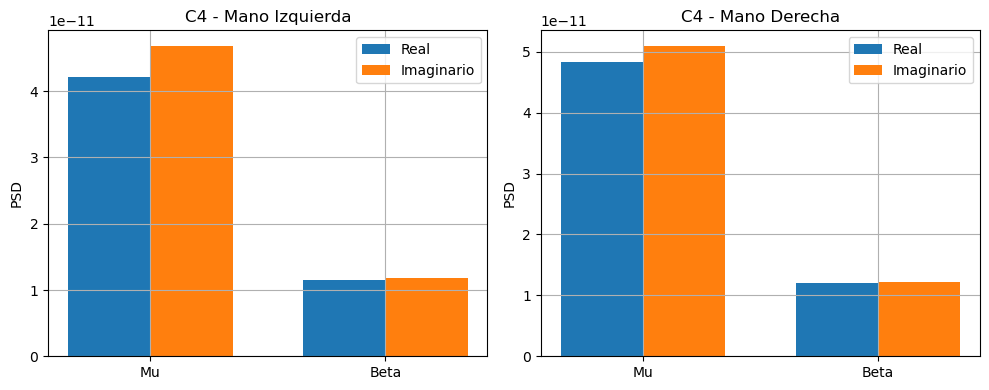

In [61]:
# Canal C4
print("Canal C4")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
barras_canal(df, "C4", "Izquierda")
plt.subplot(1,2,2)
barras_canal(df, "C4", "Derecha")
plt.show()

In [42]:
df.groupby("tarea")["mu_C3"].agg(["mean","std","median","min","max"])

,mean,std,median,min,max
tarea,,,,,
Derecha_Imaginería,3.685240e-11,3.817618e-11,2.646406e-11,5.849157e-13,2.014646e-10
Derecha_Real,3.520066e-11,3.752554e-11,2.683506e-11,5.519896e-13,2.003788e-10
Izquierda_Imaginería,3.872443e-11,4.243839e-11,2.698490e-11,5.526793e-13,2.631688e-10
Izquierda_Real,3.336644e-11,3.459683e-11,2.704736e-11,4.758844e-13,2.054694e-10


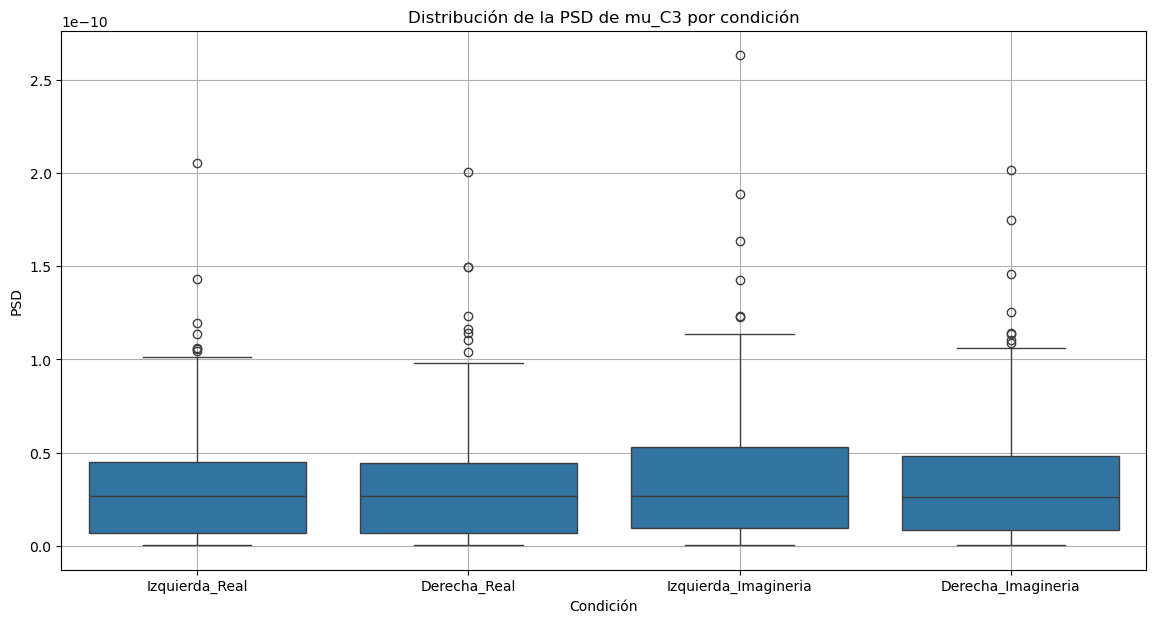

In [66]:
boxplot("mu_C3")
plt.show()

In [44]:
df.groupby("tarea")[["beta_C3"]].agg(["mean","std","median","min","max"])

beta_C3                                            \
                              mean           std        median           min   
tarea                                                                          
Derecha_Imaginería    9.052217e-12  7.904508e-12  7.899516e-12  2.169668e-13   
Derecha_Real          8.907789e-12  7.814672e-12  7.688385e-12  2.063861e-13   
Izquierda_Imaginería  9.469346e-12  8.273197e-12  8.202831e-12  2.145000e-13   
Izquierda_Real        8.941015e-12  7.737429e-12  7.114156e-12  2.131505e-13   

                                    
                               max  
tarea                               
Derecha_Imaginería    3.648277e-11  
Derecha_Real          3.066435e-11  
Izquierda_Imaginería  3.826123e-11  
Izquierda_Real        3.142875e-11

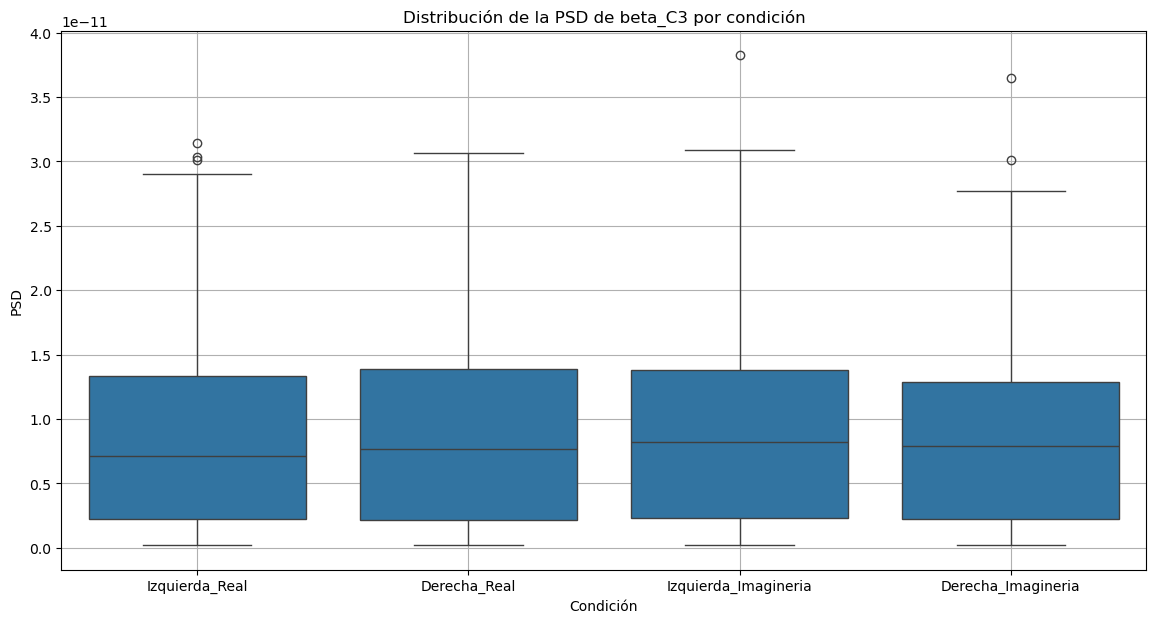

In [67]:
boxplot("beta_C3")
plt.show()

In [47]:
df.groupby("tarea")[["mu_C4"]].agg(["mean","std","median","min","max"])

mu_C4                                                        
                  mean           std        median           min           max
tarea                                                                         
der_imag  5.096824e-11  1.888905e-10  2.307857e-11  4.426033e-13  1.968310e-09
der_real  4.837881e-11  1.816042e-10  2.194865e-11  4.270508e-13  1.886208e-09
izq_imag  4.684940e-11  1.836380e-10  2.097060e-11  4.191998e-13  1.915685e-09
izq_real  4.211967e-11  1.668405e-10  2.239276e-11  4.377231e-13  1.743651e-09

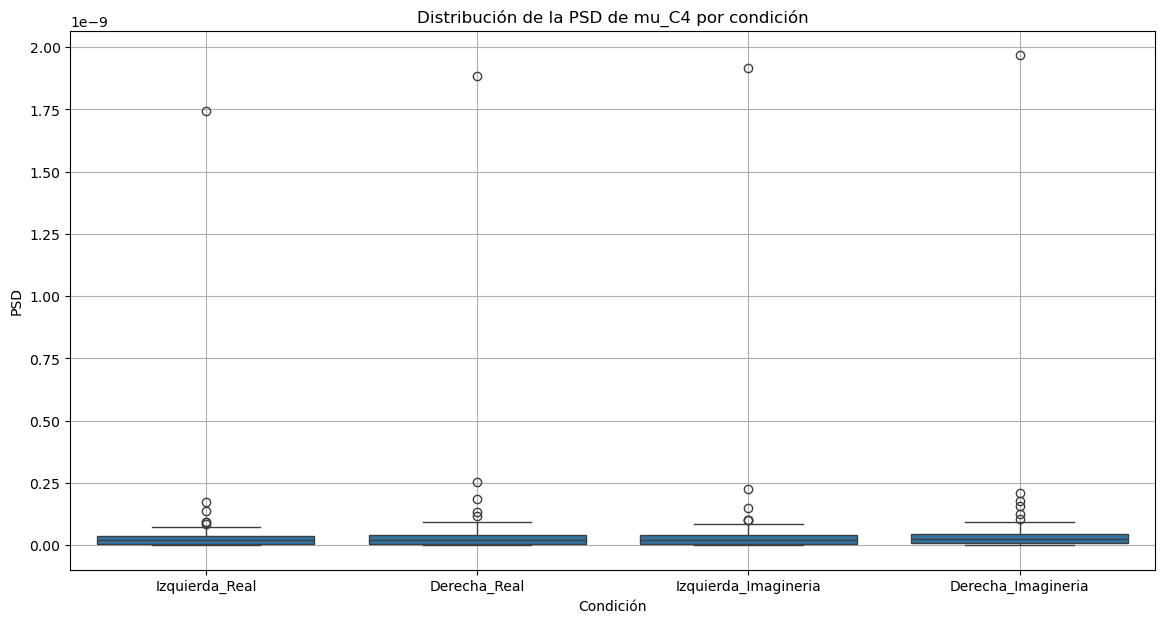

In [68]:
boxplot("mu_C4")
plt.show()

In [49]:
df.groupby("tarea")[["beta_C4"]].agg(["mean","std","median","min","max"])

beta_C4                                                        
                  mean           std        median           min           max
tarea                                                                         
der_imag  1.221319e-11  4.896542e-11  6.547431e-12  1.465753e-13  5.146594e-10
der_real  1.195008e-11  4.686047e-11  6.341225e-12  1.523035e-13  4.920194e-10
izq_imag  1.180065e-11  4.773696e-11  6.814722e-12  1.532274e-13  5.016537e-10
izq_real  1.157007e-11  4.972538e-11  5.941857e-12  1.478612e-13  5.225978e-10

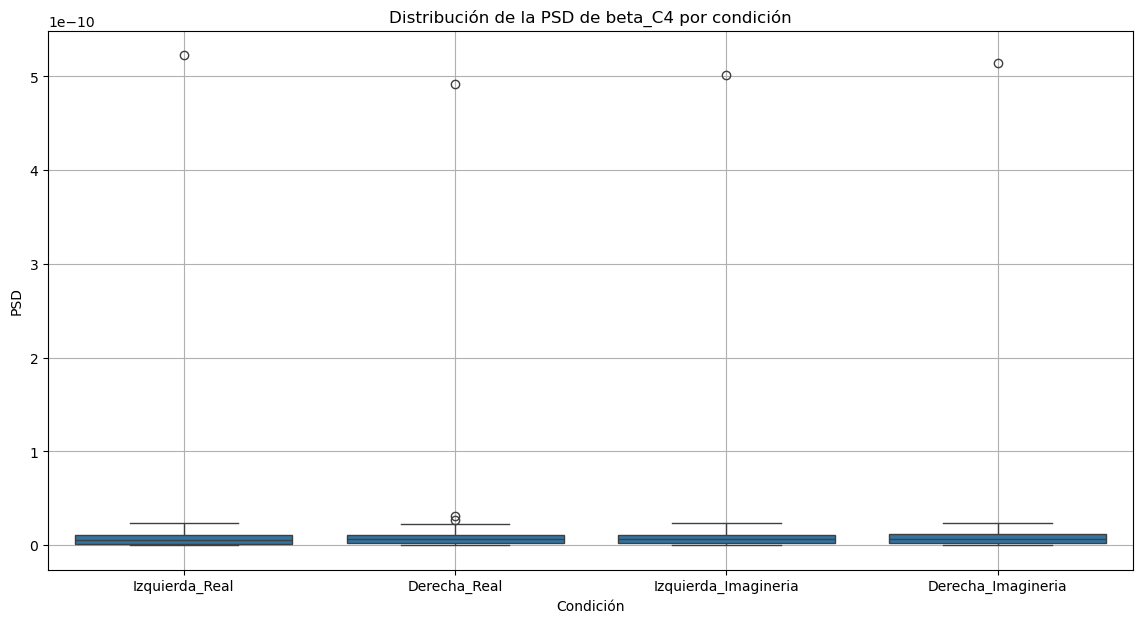

In [69]:
boxplot("beta_C4")
plt.show()

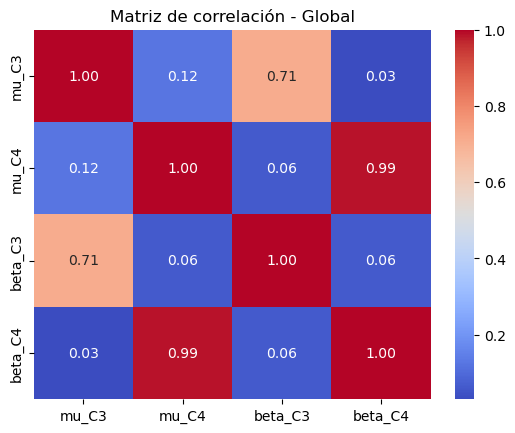

In [76]:
correlacion(df, ["mu_C3","mu_C4","beta_C3","beta_C4"])
plt.show()

**2. Análisis e hipótesis:**

In [79]:
def evaluar_hipotesis(df, var1, var2, cond1=None, cond2=None, tipo="condiciones"):
    
    # ==============================
    # CASO 1: COMPARAR CONDICIONES
    # ==============================
    if tipo == "condiciones":
        g1 = df[df["tarea"] == cond1][["sujeto", var1]].set_index("sujeto")
        g2 = df[df["tarea"] == cond2][["sujeto", var1]].set_index("sujeto")

        datos = g1.join(g2, lsuffix="_1", rsuffix="_2").dropna()

        x = datos[f"{var1}_1"]
        y = datos[f"{var1}_2"]

        comparacion = f"{cond1} vs {cond2}"
        variable = var1

    # ==============================
    # CASO 2: COMPARAR CANALES
    # ==============================
    elif tipo == "canales":
        datos = df[df["tarea"] == cond1][["sujeto", var1, var2]].dropna()
        datos = datos.set_index("sujeto")

        x = datos[var1]
        y = datos[var2]

        comparacion = f"{var1} vs {var2} ({cond1})"
        variable = f"{var1} vs {var2}"

    else:
        raise ValueError("Tipo debe ser 'condiciones' o 'canales'")

    # ==============================
    # PRUEBAS ESTADÍSTICAS
    # ==============================

    diff = x - y
    _, p_shapiro = shapiro(diff)
    normal = p_shapiro > 0.05

    if normal:
        stat, p = ttest_rel(x, y)
        prueba = "t pareado"
    else:
        stat, p = wilcoxon(x, y)
        prueba = "Wilcoxon"

    decision = "Rechaza H0" if p < 0.05 else "No rechaza H0"

    fila = {
        "Variable": variable,
        "Comparación": comparacion,
        "Shapiro (dif)": p_shapiro,
        "Normalidad": "Sí" if normal else "No",
        "Prueba": prueba,
        "p-valor": p,
        "Decisión": decision
    }

    return display(pd.DataFrame([fila]))

#### **Análisis 1:** Análisis comparativo de la densidad espectral de potencia (PSD) promedio en las bandas mu y beta entre movimientos de mano izquierda y derecha en los canales C3 y C4

In [80]:
# Uso de la función en los casos planteados anteriormente
# Canal C3
print("Canal C3:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C3", None, "Izquierda_Real", "Derecha_Real", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C3", None, "Izquierda_Imagineria", "Derecha_Imagineria", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C3", None, "Izquierda_Real", "Derecha_Real", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C3", None, "Izquierda_Imagineria", "Derecha_Imagineria", tipo = "condiciones")

# Canal C4
print("\nCanal C4:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C4", None, "Izquierda_Real", "Derecha_Real", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C4", None, "Izquierda_Imagineria", "Derecha_Imagineria", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C4", None, "Izquierda_Real", "Derecha_Real", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C4", None, "Izquierda_Imagineria", "Derecha_Imagineria", tipo = "condiciones")

Canal C3:

Resultados banda mu:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,Izquierda_Real vs Derecha_Real,2.331335e-15,No,Wilcoxon,0.666604,No rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,Izquierda_Imagineria vs Derecha_Imagineria,2.338512e-10,No,Wilcoxon,0.016993,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3,Izquierda_Real vs Derecha_Real,9.560636e-14,No,Wilcoxon,0.038225,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,Izquierda_Real vs Derecha_Real,1.142177e-17,No,Wilcoxon,0.000002,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,Izquierda_Imagineria vs Derecha_Imagineria,1.178084e-16,No,Wilcoxon,0.000172,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,Izquierda_Real vs Derecha_Real,2.155748e-19,No,Wilcoxon,0.000002,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,Izquierda_Imagineria vs Derecha_Imagineria,2.377416e-16,No,Wilcoxon,0.000145,Rechaza H0


### **Análisis 2:** Análisis comparativo de la potencia espectral (PSD) promedio en bandas mu y beta entre movimiento real e imaginario en los canales C3 y C4 según la mano ejecutante

In [81]:
# Uso de la función en los casos planteados anteriormente
# Canal C3
print("Canal C3:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C3", None, "Izquierda_Real", "Izquierda_Imagineria", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C3", None, "Derecha_Real", "Derecha_Imagineria", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C3", None, "Izquierda_Real", "Izquierda_Imagineria", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C3", None, "Derecha_Real", "Derecha_Imagineria", tipo = "condiciones")

# Canal C4
print("\nCanal C4:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C4", None, "Izquierda_Real", "Izquierda_Imagineria", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C4", None, "Derecha_Real", "Derecha_Imagineria", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C4", None, "Izquierda_Real", "Izquierda_Imagineria", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C4", None, "Derecha_Real", "Derecha_Imagineria", tipo = "condiciones")

Canal C3:

Resultados banda mu:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,Izquierda_Real vs Izquierda_Imagineria,4.438902e-10,No,Wilcoxon,0.000026,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,Derecha_Real vs Derecha_Imagineria,1.663078e-12,No,Wilcoxon,0.003943,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3,Izquierda_Real vs Izquierda_Imagineria,0.000002,No,Wilcoxon,0.015907,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,Izquierda_Real vs Izquierda_Imagineria,4.710483e-18,No,Wilcoxon,0.000057,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,Derecha_Real vs Derecha_Imagineria,2.266776e-13,No,Wilcoxon,0.008345,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,Izquierda_Real vs Izquierda_Imagineria,1.451600e-15,No,Wilcoxon,0.000936,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,Derecha_Real vs Derecha_Imagineria,3.094757e-14,No,Wilcoxon,0.007163,Rechaza H0


### **Análisis 3:** Análisis comparativo de la potencia espectral (PSD) promedio entre los canales C3 y C4 en las bandas mu y beta durante tareas de movimiento real e imaginario la mano ejecutante

In [82]:
# Uso de la función en los casos planteados anteriormente

# Mano izquierda
print("Mano izquierda:")

# 1. Banda mu
print("\nResultados banda mu (C3 vs C4):")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "Izquierda_Real", tipo="canales")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "Izquierda_Imagineria", tipo="canales")

# 2. Banda beta
print("\nResultados banda beta (C3 vs C4):")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "Izquierda_Real", tipo="canales")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "Izquierda_Imagineria", tipo="canales")

# Mano derecha
print("\nMano derecha:")

# 1. Banda mu
print("\nResultados banda mu (C3 vs C4):")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "Derecha_Real", tipo="canales")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "Derecha_Imagineria", tipo="canales")

# 2. Banda beta
print("\nResultados banda beta (C3 vs C4):")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "Derecha_Real", tipo="canales")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "Derecha_Imagineria", tipo="canales")

Mano izquierda:

Resultados banda mu (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (Izquierda_Real),8.607931e-23,No,Wilcoxon,3.452685e-13,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (Izquierda_Imagineria),1.017287e-22,No,Wilcoxon,8.861913e-14,Rechaza H0



Resultados banda beta (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (Izquierda_Real),8.587309e-23,No,Wilcoxon,4.333730e-14,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (Derecha_Real),8.950110e-23,No,Wilcoxon,8.639473e-07,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (Derecha_Imagineria),9.432228e-23,No,Wilcoxon,0.000168,Rechaza H0



Resultados banda beta (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (Derecha_Real),8.686484e-23,No,Wilcoxon,2.413403e-08,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (Derecha_Imagineria),8.110220e-23,No,Wilcoxon,2.170261e-09,Rechaza H0
